# Learning-free semantic attention and component RDMs

This notebook builds a transparent attention-like memory model from the identity-masked task embeddings created in \`semantics_v1.ipynb\`. It does not learn projections or fit parameters to behavior or neural data.

For current trial \(t\):

- **Query** \(q_t\): the pair-mean embedding of the current situation and its two response options.
- **Key** \(k_i\): the corresponding pair-mean embedding for earlier interaction \(i\).
- **Value** \(v_i\): the situation-plus-response embedding actually chosen on earlier interaction \(i\).
- **Attention** \(\alpha_{ti}\): a causal softmax of cosine query-key similarity.
- **Retrieved key** \(\kappa_t = \sum_i \alpha_{ti}k_i\).
- **Retrieved value** \(m_t = \sum_i \alpha_{ti}v_i\).
- **Update** \(u_t = v_t - m_t\).

The main model uses an explicit same-character gate because character identity was deliberately masked from the embedded text. A global, ungated model remains available as a diagnostic. Temperature is never fit here: a fixed beta grid is treated as sensitivity analysis.

The output is a matched family of 60 × 60 RDMs and vectorized upper-triangle RDVs for the query, current chosen value, retrieved key, retrieved value, memory coherence, history-relative update, and attention-allocation pattern.

In [2]:
from pathlib import Path
import pickle
from typing import Mapping, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.spatial.distance import pdist, squareform

from shared.main import incl_subs, load_behavior

sns.set_context("notebook")
sns.set_style("white")

## Load the saved semantic task embeddings

The bundle stores \`rep_manifest\` and \`X\` in exact row alignment. The text-manifest embedding indices do **not** index rows of \`X\`, so all lookup tables below are built from \`rep_manifest\`.

In [3]:
BUNDLE_FILENAME = "semantic_features_bundle_identity_masked.pkl"


def resolve_bundle_path(filename=BUNDLE_FILENAME):
    """Find the bundle from either the repository root or notebook folder."""
    cwd = Path.cwd().resolve()
    candidates = []

    for root in (cwd, *cwd.parents):
        candidates.extend(
            [
                root / filename,
                root / "code" / "analyses" / "fmri" / filename,
            ]
        )

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"Could not find {filename!r} from {cwd}. "
        "Run semantics_v1.ipynb first or update BUNDLE_FILENAME."
    )


BUNDLE_PATH = resolve_bundle_path()

with BUNDLE_PATH.open("rb") as file:
    bundle = pickle.load(file)

required_bundle_keys = {
    "bundle_version",
    "choices",
    "text_manifest",
    "rep_manifest",
    "X",
}
missing_bundle_keys = required_bundle_keys - set(bundle)
if missing_bundle_keys:
    raise KeyError(f"Bundle is missing keys: {sorted(missing_bundle_keys)}")

choices = bundle["choices"].copy()
text_manifest = bundle["text_manifest"].copy()
rep_manifest = bundle["rep_manifest"].copy()
X = np.asarray(bundle["X"], dtype=float)

if len(rep_manifest) != len(X):
    raise ValueError("rep_manifest must align row-for-row with X.")

print("Loaded:", BUNDLE_PATH)
print("Bundle version:", bundle["bundle_version"])
print("Choices:", choices.shape)
print("Representations:", X.shape)

Loaded: /Users/matty_gee/Projects/SocialCUD/code/analyses/fmri/semantic_features_bundle_identity_masked.pkl
Bundle version: identity_masked_text_vs_running_mean_v1
Choices: (60, 33)
Representations: (3000, 1536)


In [4]:
def prepare_task_embeddings(
    choices,
    text_manifest,
    rep_manifest,
    embeddings,
    *,
    context="previous_slide",
):
    """
    Extract one query/key vector and two possible value vectors per decision.

    Query/key:
        context == previous_slide, rep_type == choice_pair_mean

    Values:
        context == previous_slide, rep_type == option
    """
    task = (
        choices
        .sort_values("trial_num")
        .reset_index(drop=True)
        .copy()
    )

    task["decision_num"] = pd.to_numeric(
        task["decision_num"],
        errors="raise",
    ).astype(int)

    manifest = rep_manifest.reset_index(drop=True).copy()
    manifest["embedding_row"] = np.arange(len(manifest))

    local = manifest.loc[
        manifest["context"].eq(context)
    ].copy()

    pair_rows = local.loc[
        local["rep_type"].eq("choice_pair_mean")
    ].copy()

    if len(pair_rows) != len(task):
        raise ValueError(
            f"Expected {len(task)} pair-mean rows; found {len(pair_rows)}."
        )

    if pair_rows["decision_num"].duplicated().any():
        raise ValueError("Expected one pair-mean vector per decision.")

    pair_rows["decision_num"] = pd.to_numeric(
        pair_rows["decision_num"],
        errors="raise",
    ).astype(int)

    pair_rows = pair_rows.set_index("decision_num")

    decision_order = task["decision_num"].to_numpy()
    missing_queries = set(decision_order) - set(pair_rows.index)
    if missing_queries:
        raise KeyError(f"Missing query/key decisions: {sorted(missing_queries)}")

    query_keys = embeddings[
        pair_rows.loc[decision_order, "embedding_row"].to_numpy(dtype=int)
    ]

    option_rows = local.loc[
        local["rep_type"].eq("option")
    ].copy()

    option_rows["decision_num"] = pd.to_numeric(
        option_rows["decision_num"],
        errors="raise",
    ).astype(int)

    option_rows["direction"] = pd.to_numeric(
        option_rows["direction"],
        errors="raise",
    ).astype(int)

    if option_rows.duplicated(["decision_num", "direction"]).any():
        raise ValueError(
            "Expected one option vector per decision and signed direction."
        )

    direction_sets = (
        option_rows
        .groupby("decision_num")["direction"]
        .agg(lambda values: sorted(values.tolist()))
    )
    if not direction_sets.map(lambda values: values == [-1, 1]).all():
        raise ValueError("Every decision must have one -1 and one +1 value.")

    value_lookup = {
        (int(row.decision_num), int(row.direction)):
            embeddings[int(row.embedding_row)]
        for row in option_rows.itertuples()
    }

    local_text = text_manifest.loc[
        text_manifest["context"].eq(context)
    ].copy()

    local_text["decision_num"] = pd.to_numeric(
        local_text["decision_num"],
        errors="raise",
    ).astype(int)

    local_text["direction"] = pd.to_numeric(
        local_text["direction"],
        errors="raise",
    ).astype(int)

    value_text_lookup = {
        (int(row.decision_num), int(row.direction)): {
            "option_idx": int(row.option_idx),
            "option_text": row.option_text,
            "embedded_text": row.text,
        }
        for row in local_text.itertuples()
    }

    return task, query_keys, value_lookup, value_text_lookup


(
    task,
    query_key_embeddings,
    VALUE_LOOKUP,
    VALUE_TEXT_LOOKUP,
) = prepare_task_embeddings(
    choices=choices,
    text_manifest=text_manifest,
    rep_manifest=rep_manifest,
    embeddings=X,
)

print("Task decisions:", len(task))
print("Query/key matrix:", query_key_embeddings.shape)
print("Possible chosen values:", len(VALUE_LOOKUP))
print(
    "Pair-mean norm range:",
    np.linalg.norm(query_key_embeddings, axis=1).min(),
    np.linalg.norm(query_key_embeddings, axis=1).max(),
)

Task decisions: 60
Query/key matrix: (60, 1536)
Possible chosen values: 120
Pair-mean norm range: 0.9286230783261243 0.993816782372931


## Reconstruct participant-specific chosen values

The task-level queries and keys are shared across participants. Values are participant-specific because each prior memory contains the response that participant actually chose. Neutral trials are removed to align behavior with the 60 non-neutral semantic decisions.

In [5]:
NEUTRAL_TRIAL_INDICES = np.array([14, 15, 35])


def remove_neutral_behavior_rows(behavior):
    """Return the 60 non-neutral decision rows."""
    behavior = behavior.reset_index(drop=True).copy()

    if len(behavior) == 60:
        return behavior

    if len(behavior) != 63:
        raise ValueError(
            f"Expected 60 or 63 behavioral decisions; found {len(behavior)}."
        )

    role_column = next(
        (
            column
            for column in ("character_role_num", "char_role_num")
            if column in behavior.columns
        ),
        None,
    )

    if role_column is not None:
        roles = pd.to_numeric(
            behavior[role_column],
            errors="coerce",
        )
        keep = ~roles.eq(6)

        if int(keep.sum()) == 60:
            return behavior.loc[keep].reset_index(drop=True)

    return behavior.drop(
        index=NEUTRAL_TRIAL_INDICES
    ).reset_index(drop=True)


def participant_choice_directions(sub_id):
    """
    Return one signed choice direction per non-neutral task decision.

    Affiliation and power trials both use -1/+1. Missing responses remain NaN.
    """
    behavior = load_behavior(
        sub_id,
        neutrals=True,
        on_missing="raise",
    )
    behavior = remove_neutral_behavior_rows(behavior)

    required = {"affil_decision", "power_decision"}
    missing = required - set(behavior.columns)
    if missing:
        raise KeyError(f"{sub_id}: missing behavior columns {sorted(missing)}")

    decisions = (
        behavior[["affil_decision", "power_decision"]]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float)
    )

    active = np.isfinite(decisions) & ~np.isclose(decisions, 0.0)

    if np.any(active.sum(axis=1) > 1):
        bad = np.flatnonzero(active.sum(axis=1) > 1).tolist()
        raise ValueError(f"{sub_id}: both dimensions active on rows {bad}.")

    directions = np.full(len(decisions), np.nan, dtype=float)
    has_choice = active.sum(axis=1) == 1
    directions[has_choice] = np.sum(
        np.where(active[has_choice], decisions[has_choice], 0.0),
        axis=1,
    )

    invalid = has_choice & ~np.isin(directions, [-1, 1])
    if invalid.any():
        bad = np.flatnonzero(invalid).tolist()
        raise ValueError(f"{sub_id}: invalid choice directions on rows {bad}.")

    observed_dimension = np.where(
        active[:, 0],
        "affil",
        "power",
    )
    expected_dimension = task["dimension"].astype(str).to_numpy()

    mismatch = has_choice & (observed_dimension != expected_dimension)
    if mismatch.any():
        bad = np.flatnonzero(mismatch).tolist()
        raise ValueError(f"{sub_id}: task-dimension mismatch on rows {bad}.")

    return directions

## Causal semantic attention

Queries and keys are explicitly L2-normalized, so their dot product is cosine similarity. We use \(\beta \times \mathrm{cosine}\), not transformer-style division by \(\sqrt{d}\), because unit sentence embeddings would otherwise produce nearly uniform logits.

An optional recency term supports matched controls:

\[
\mathrm{logit}_{ti}
=
\beta q_t^\top k_i
-
(\mathrm{lag}_{ti}-1)/\tau.
\]

Setting beta to zero with no recency term gives an exact uniform average of eligible prior chosen values.

In [6]:
def row_normalize(matrix, eps=1e-12):
    """L2-normalize finite, nonzero rows and mark other rows NaN."""
    matrix = np.asarray(matrix, dtype=float)
    norms = np.linalg.norm(matrix, axis=1)
    valid = np.isfinite(matrix).all(axis=1) & (norms > eps)

    units = np.full_like(matrix, np.nan, dtype=float)
    units[valid] = matrix[valid] / norms[valid, None]

    return units, valid


def compute_attention_components(
    choice_directions,
    *,
    beta,
    character_gate=True,
    recency_tau=None,
    eps=1e-12,
):
    """
    Compute trialwise query, retrieved-key, retrieved-value, and update states.

    No learned Q/K/V projections are used.
    """
    beta = float(beta)
    if beta < 0:
        raise ValueError("beta must be non-negative.")

    if recency_tau is not None:
        recency_tau = float(recency_tau)
        if recency_tau <= 0:
            raise ValueError("recency_tau must be positive or None.")

    directions = np.asarray(choice_directions, dtype=float)
    if directions.shape != (len(task),):
        raise ValueError(
            f"Expected {len(task)} choices; received {directions.shape}."
        )

    queries, query_valid = row_normalize(query_key_embeddings, eps=eps)
    keys = queries.copy()

    current_values = np.full_like(queries, np.nan, dtype=float)

    for trial, (decision_num, direction) in enumerate(
        zip(task["decision_num"], directions)
    ):
        if not np.isfinite(direction):
            continue

        lookup_key = (int(decision_num), int(direction))
        if lookup_key not in VALUE_LOOKUP:
            raise KeyError(f"No semantic value for {lookup_key}.")

        vector = np.asarray(VALUE_LOOKUP[lookup_key], dtype=float)
        norm = np.linalg.norm(vector)

        if not np.isfinite(vector).all() or norm <= eps:
            raise ValueError(f"Invalid semantic value for {lookup_key}.")

        current_values[trial] = vector / norm

    value_valid = (
        np.isfinite(current_values).all(axis=1)
        & (np.linalg.norm(np.nan_to_num(current_values), axis=1) > eps)
    )

    n_trials, n_dims = queries.shape

    attention = np.full((n_trials, n_trials), np.nan, dtype=float)
    similarities = np.full((n_trials, n_trials), np.nan, dtype=float)
    retrieved_keys = np.full((n_trials, n_dims), np.nan, dtype=float)
    retrieved_values = np.full((n_trials, n_dims), np.nan, dtype=float)
    updates = np.full((n_trials, n_dims), np.nan, dtype=float)

    n_memories = np.zeros(n_trials, dtype=int)
    attention_entropy = np.full(n_trials, np.nan, dtype=float)
    effective_memories = np.full(n_trials, np.nan, dtype=float)
    maximum_weight = np.full(n_trials, np.nan, dtype=float)

    characters = task["character"].astype(str).to_numpy()
    character_positions = pd.to_numeric(
        task["character_decision_num"],
        errors="coerce",
    ).to_numpy(dtype=float)

    for current_trial in range(n_trials):
        if not query_valid[current_trial]:
            continue

        eligible = np.arange(current_trial)
        eligible = eligible[value_valid[eligible] & query_valid[eligible]]

        if character_gate:
            eligible = eligible[
                characters[eligible] == characters[current_trial]
            ]

        if len(eligible) == 0:
            continue

        cosine_similarity = keys[eligible] @ queries[current_trial]
        logits = beta * cosine_similarity

        if recency_tau is not None:
            if (
                character_gate
                and np.isfinite(character_positions[current_trial])
                and np.isfinite(character_positions[eligible]).all()
            ):
                lags = (
                    character_positions[current_trial]
                    - character_positions[eligible]
                )
            else:
                lags = current_trial - eligible

            logits = logits - (lags - 1.0) / recency_tau

        logits = logits - np.max(logits)
        weights = np.exp(logits)
        weights = weights / weights.sum()

        attention[current_trial] = 0.0
        attention[current_trial, eligible] = weights
        similarities[current_trial, eligible] = cosine_similarity

        retrieved_keys[current_trial] = np.sum(
            weights[:, None] * keys[eligible],
            axis=0,
        )
        retrieved_values[current_trial] = np.sum(
            weights[:, None] * current_values[eligible],
            axis=0,
        )

        if value_valid[current_trial]:
            updates[current_trial] = (
                current_values[current_trial]
                - retrieved_values[current_trial]
            )

        n_memories[current_trial] = len(eligible)
        entropy = -np.sum(weights * np.log(np.clip(weights, eps, None)))
        attention_entropy[current_trial] = entropy
        effective_memories[current_trial] = np.exp(entropy)
        maximum_weight[current_trial] = weights.max()

    trial_features = task[
        [
            "decision_num",
            "trial_num",
            "character",
            "character_decision_num",
            "dimension",
        ]
    ].copy()

    trial_features["choice_direction"] = directions
    trial_features["n_memories"] = n_memories
    trial_features["attention_entropy"] = attention_entropy
    trial_features["effective_memories"] = effective_memories
    trial_features["maximum_attention_weight"] = maximum_weight
    trial_features["memory_coherence"] = np.linalg.norm(
        retrieved_values,
        axis=1,
    )

    return {
        "beta": beta,
        "character_gate": bool(character_gate),
        "recency_tau": recency_tau,
        "query": queries,
        "key": keys,
        "current_value": current_values,
        "attention": attention,
        "query_key_similarity": similarities,
        "retrieved_key": retrieved_keys,
        "retrieved_value": retrieved_values,
        "update": updates,
        "trial_features": trial_features,
    }

## Component RDMs and matched RDVs

Semantic vector components use cosine distance. Memory coherence is the absolute difference between retrieved-value norms. Attention-allocation patterns use Jensen–Shannon distance between fixed-length, zero-padded attention distributions.

For matched RSA comparisons, all components use one common trial mask. Under complete, same-character-gated histories this excludes the first interaction with each of five characters, leaving 55 trials and 1,485 finite trial pairs. Undefined memories remain NaN rather than being represented by an arbitrary zero vector.

In [7]:
def cosine_rdm(matrix, eps=1e-12):
    """Pairwise cosine-distance RDM with NaNs for invalid rows."""
    matrix = np.asarray(matrix, dtype=float)
    units, valid = row_normalize(matrix, eps=eps)

    rdm = np.full((len(matrix), len(matrix)), np.nan, dtype=float)

    if valid.any():
        similarity = np.clip(
            units[valid] @ units[valid].T,
            -1.0,
            1.0,
        )
        distances = np.clip(1.0 - similarity, 0.0, 2.0)
        np.fill_diagonal(distances, 0.0)
        rdm[np.ix_(valid, valid)] = distances

    return rdm


def absolute_difference_rdm(values):
    """Pairwise absolute-difference RDM for a scalar trial feature."""
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    rdm = np.full((len(values), len(values)), np.nan, dtype=float)

    if valid.any():
        distances = np.abs(
            values[valid, None] - values[None, valid]
        )
        rdm[np.ix_(valid, valid)] = distances

    return rdm


def attention_js_rdm(attention, eps=1e-12):
    """
    Jensen-Shannon distance between attention-allocation distributions.

    Rows with no eligible history remain invalid.
    """
    attention = np.asarray(attention, dtype=float)
    row_sums = np.nansum(attention, axis=1)

    valid = (
        np.isfinite(attention).all(axis=1)
        & (row_sums > eps)
    )

    rdm = np.full(
        (len(attention), len(attention)),
        np.nan,
        dtype=float,
    )

    if valid.any():
        distributions = attention[valid] / row_sums[valid, None]
        distances = squareform(
            pdist(distributions, metric="jensenshannon")
        )
        np.fill_diagonal(distances, 0.0)
        rdm[np.ix_(valid, valid)] = distances

    return rdm


def vectorize_rdm(rdm):
    """Return the upper triangle in the ordering used by RSA models."""
    rdm = np.asarray(rdm, dtype=float)
    return rdm[np.triu_indices_from(rdm, k=1)]


def make_component_rdms(
    components,
    *,
    common_history_mask=True,
    eps=1e-12,
):
    """
    Build matched RDMs/RDVs for the components of the attention process.
    """
    vector_components = {
        "attention_query_direction":
            components["query"],
        "semantic_choice_direction":
            components["current_value"],
        "attention_retrieved_key_direction":
            components["retrieved_key"],
        "semantic_attention_history_direction":
            components["retrieved_value"],
        "semantic_attention_update_direction":
            components["update"],
    }

    memory_strength = np.linalg.norm(
        components["retrieved_value"],
        axis=1,
    )

    common_trials = np.ones(len(task), dtype=bool)

    if common_history_mask:
        for matrix in vector_components.values():
            matrix = np.asarray(matrix, dtype=float)
            common_trials &= (
                np.isfinite(matrix).all(axis=1)
                & (np.linalg.norm(np.nan_to_num(matrix), axis=1) > eps)
            )

        attention = np.asarray(components["attention"], dtype=float)
        common_trials &= (
            np.isfinite(attention).all(axis=1)
            & (attention.sum(axis=1) > eps)
            & np.isfinite(memory_strength)
        )

    def mask_rows(values):
        values = np.asarray(values, dtype=float).copy()
        values[~common_trials] = np.nan
        return values

    rdm_matrices = {
        name: cosine_rdm(mask_rows(matrix), eps=eps)
        for name, matrix in vector_components.items()
    }

    rdm_matrices[
        "semantic_attention_history_magnitude"
    ] = absolute_difference_rdm(
        mask_rows(memory_strength)
    )

    rdm_matrices[
        "attention_allocation"
    ] = attention_js_rdm(
        mask_rows(components["attention"]),
        eps=eps,
    )

    rdvs = {
        name: vectorize_rdm(rdm)
        for name, rdm in rdm_matrices.items()
    }

    expected_finite_pairs = vectorize_rdm(
        np.outer(common_trials, common_trials).astype(float)
    ).astype(bool)

    for name, rdv in rdvs.items():
        if not np.array_equal(np.isfinite(rdv), expected_finite_pairs):
            raise ValueError(
                f"{name}: finite-pair mask does not match the common mask."
            )

    return {
        "rdms": rdm_matrices,
        "rdvs": rdvs,
        "common_trial_mask": common_trials,
        "common_pair_mask": expected_finite_pairs,
    }

## Worked participant and unfitted beta sensitivity

The primary beta below is only a display default. All beta values are retained, and none is selected using behavior or neural fit. The same-character gate is the mechanistic default; recency-only and uniform histories are constructed as matched controls.

In [8]:
CHARACTER_GATE = True
BETA_GRID = (0.0, 1.0, 2.0, 5.0, 10.0, 20.0)
PRIMARY_BETA = 10.0
RECENCY_CONTROL_TAU = 2.0

EXAMPLE_SUBJECT = incl_subs[0]
example_choice_directions = participant_choice_directions(
    EXAMPLE_SUBJECT
)

components_by_beta = {}
rdms_by_beta = {}

for beta in BETA_GRID:
    components = compute_attention_components(
        example_choice_directions,
        beta=beta,
        character_gate=CHARACTER_GATE,
        recency_tau=None,
    )
    components_by_beta[beta] = components
    rdms_by_beta[beta] = make_component_rdms(components)

primary_components = components_by_beta[PRIMARY_BETA]
primary_rdms = rdms_by_beta[PRIMARY_BETA]
candidate_rdms = primary_rdms["rdms"]
candidate_rdvs = primary_rdms["rdvs"]

uniform_components = components_by_beta[0.0]
uniform_rdms = rdms_by_beta[0.0]

recency_components = compute_attention_components(
    example_choice_directions,
    beta=0.0,
    character_gate=CHARACTER_GATE,
    recency_tau=RECENCY_CONTROL_TAU,
)
recency_rdms = make_component_rdms(recency_components)

semantic_plus_recency_components = compute_attention_components(
    example_choice_directions,
    beta=PRIMARY_BETA,
    character_gate=CHARACTER_GATE,
    recency_tau=RECENCY_CONTROL_TAU,
)
semantic_plus_recency_rdms = make_component_rdms(
    semantic_plus_recency_components
)

print("Example subject:", EXAMPLE_SUBJECT)
print("Observed choices:", np.isfinite(example_choice_directions).sum())
print(
    "Common attention trials:",
    primary_rdms["common_trial_mask"].sum(),
)
print(
    "Finite candidate trial pairs:",
    primary_rdms["common_pair_mask"].sum(),
)
print("RDV length:", len(next(iter(candidate_rdvs.values()))))
print("Candidate RDMs:", list(candidate_rdms))

Example subject: 18001
Observed choices: 60
Common attention trials: 55
Finite candidate trial pairs: 1485
RDV length: 1770
Candidate RDMs: ['attention_query_direction', 'semantic_choice_direction', 'attention_retrieved_key_direction', 'semantic_attention_history_direction', 'semantic_attention_update_direction', 'semantic_attention_history_magnitude', 'attention_allocation']


In [9]:
def validate_attention_model(
    components,
    rdm_bundle,
    *,
    expect_character_gate,
    atol=1e-10,
):
    """Fail fast on causal, normalization, gating, and RDM-mask errors."""
    attention = np.asarray(components["attention"], dtype=float)
    valid_rows = np.isfinite(attention).all(axis=1)

    if not np.allclose(
        attention[valid_rows].sum(axis=1),
        1.0,
        atol=atol,
    ):
        raise AssertionError("Valid attention rows must sum to one.")

    future_and_current = np.triu(
        np.nan_to_num(attention, nan=0.0),
        k=0,
    )
    if not np.allclose(future_and_current, 0.0, atol=atol):
        raise AssertionError("Attention leaked to current or future trials.")

    if expect_character_gate:
        characters = task["character"].astype(str).to_numpy()
        for current_trial in np.flatnonzero(valid_rows):
            wrong_character = characters != characters[current_trial]
            if not np.allclose(
                attention[current_trial, wrong_character],
                0.0,
                atol=atol,
            ):
                raise AssertionError(
                    "Character-gated attention reached another character."
                )

    finite_masks = {
        name: np.isfinite(rdv)
        for name, rdv in rdm_bundle["rdvs"].items()
    }
    reference = next(iter(finite_masks.values()))

    if not all(
        np.array_equal(mask, reference)
        for mask in finite_masks.values()
    ):
        raise AssertionError("Candidate RDVs do not share one finite mask.")

    return {
        "valid_attention_rows": int(valid_rows.sum()),
        "common_trials": int(rdm_bundle["common_trial_mask"].sum()),
        "finite_trial_pairs": int(reference.sum()),
    }


validation_summary = validate_attention_model(
    primary_components,
    primary_rdms,
    expect_character_gate=CHARACTER_GATE,
)

# beta = 0 must give equal positive weights within every eligible history.
uniform_attention = uniform_components["attention"]
uniform_deviations = []

for row in uniform_attention:
    if not np.isfinite(row).all():
        continue
    positive = row[row > 0]
    uniform_deviations.append(
        0.0 if len(positive) <= 1 else np.ptp(positive)
    )

if max(uniform_deviations, default=0.0) > 1e-12:
    raise AssertionError("beta=0 did not produce uniform attention.")

print(validation_summary)
print("Maximum beta=0 within-row weight range:", max(uniform_deviations))

{'valid_attention_rows': 55, 'common_trials': 55, 'finite_trial_pairs': 1485}
Maximum beta=0 within-row weight range: 0.0


In [10]:
def paired_rdv_correlation(rdv_a, rdv_b, eps=1e-12):
    """Pearson correlation over matching finite trial pairs."""
    rdv_a = np.asarray(rdv_a, dtype=float)
    rdv_b = np.asarray(rdv_b, dtype=float)

    keep = np.isfinite(rdv_a) & np.isfinite(rdv_b)
    a = rdv_a[keep]
    b = rdv_b[keep]

    if len(a) < 3 or np.std(a) <= eps or np.std(b) <= eps:
        return np.nan

    return float(np.corrcoef(a, b)[0, 1])


sensitivity_rows = []

for beta in BETA_GRID:
    features = components_by_beta[beta]["trial_features"]
    rdm_bundle = rdms_by_beta[beta]

    valid_history = features["n_memories"].to_numpy() > 0

    sensitivity_rows.append(
        {
            "beta": beta,
            "mean_effective_memories":
                features.loc[valid_history, "effective_memories"].mean(),
            "mean_maximum_weight":
                features.loc[valid_history, "maximum_attention_weight"].mean(),
            "mean_memory_coherence":
                features.loc[valid_history, "memory_coherence"].mean(),
            "history_RDV_r_with_uniform":
                paired_rdv_correlation(
                    rdm_bundle["rdvs"][
                        "semantic_attention_history_direction"
                    ],
                    uniform_rdms["rdvs"][
                        "semantic_attention_history_direction"
                    ],
                ),
            "update_RDV_r_with_uniform":
                paired_rdv_correlation(
                    rdm_bundle["rdvs"][
                        "semantic_attention_update_direction"
                    ],
                    uniform_rdms["rdvs"][
                        "semantic_attention_update_direction"
                    ],
                ),
            "allocation_RDV_r_with_uniform":
                paired_rdv_correlation(
                    rdm_bundle["rdvs"]["attention_allocation"],
                    uniform_rdms["rdvs"]["attention_allocation"],
                ),
        }
    )

beta_sensitivity = pd.DataFrame(sensitivity_rows)
display(beta_sensitivity.round(3))

,beta,mean_effective_memories,mean_maximum_weight,mean_memory_coherence,history_RDV_r_with_uniform,update_RDV_r_with_uniform,allocation_RDV_r_with_uniform
0,0.0,6.000,0.275,0.808,1.000,1.000,1.000
1,1.0,5.982,0.292,0.810,0.999,0.997,1.000
2,2.0,5.931,0.310,0.813,0.997,0.989,0.999
3,5.0,5.608,0.366,0.824,0.981,0.935,0.991
4,10.0,4.775,0.457,0.846,0.924,0.780,0.960
5,20.0,3.335,0.602,0.886,0.772,0.495,0.843


## Inspect the candidate geometries

The first figure shows the seven matched component RDMs. White rows and columns are trials excluded by the common history mask. Each panel uses its own robust color scale because cosine, scalar-difference, and Jensen–Shannon distances have different ranges.

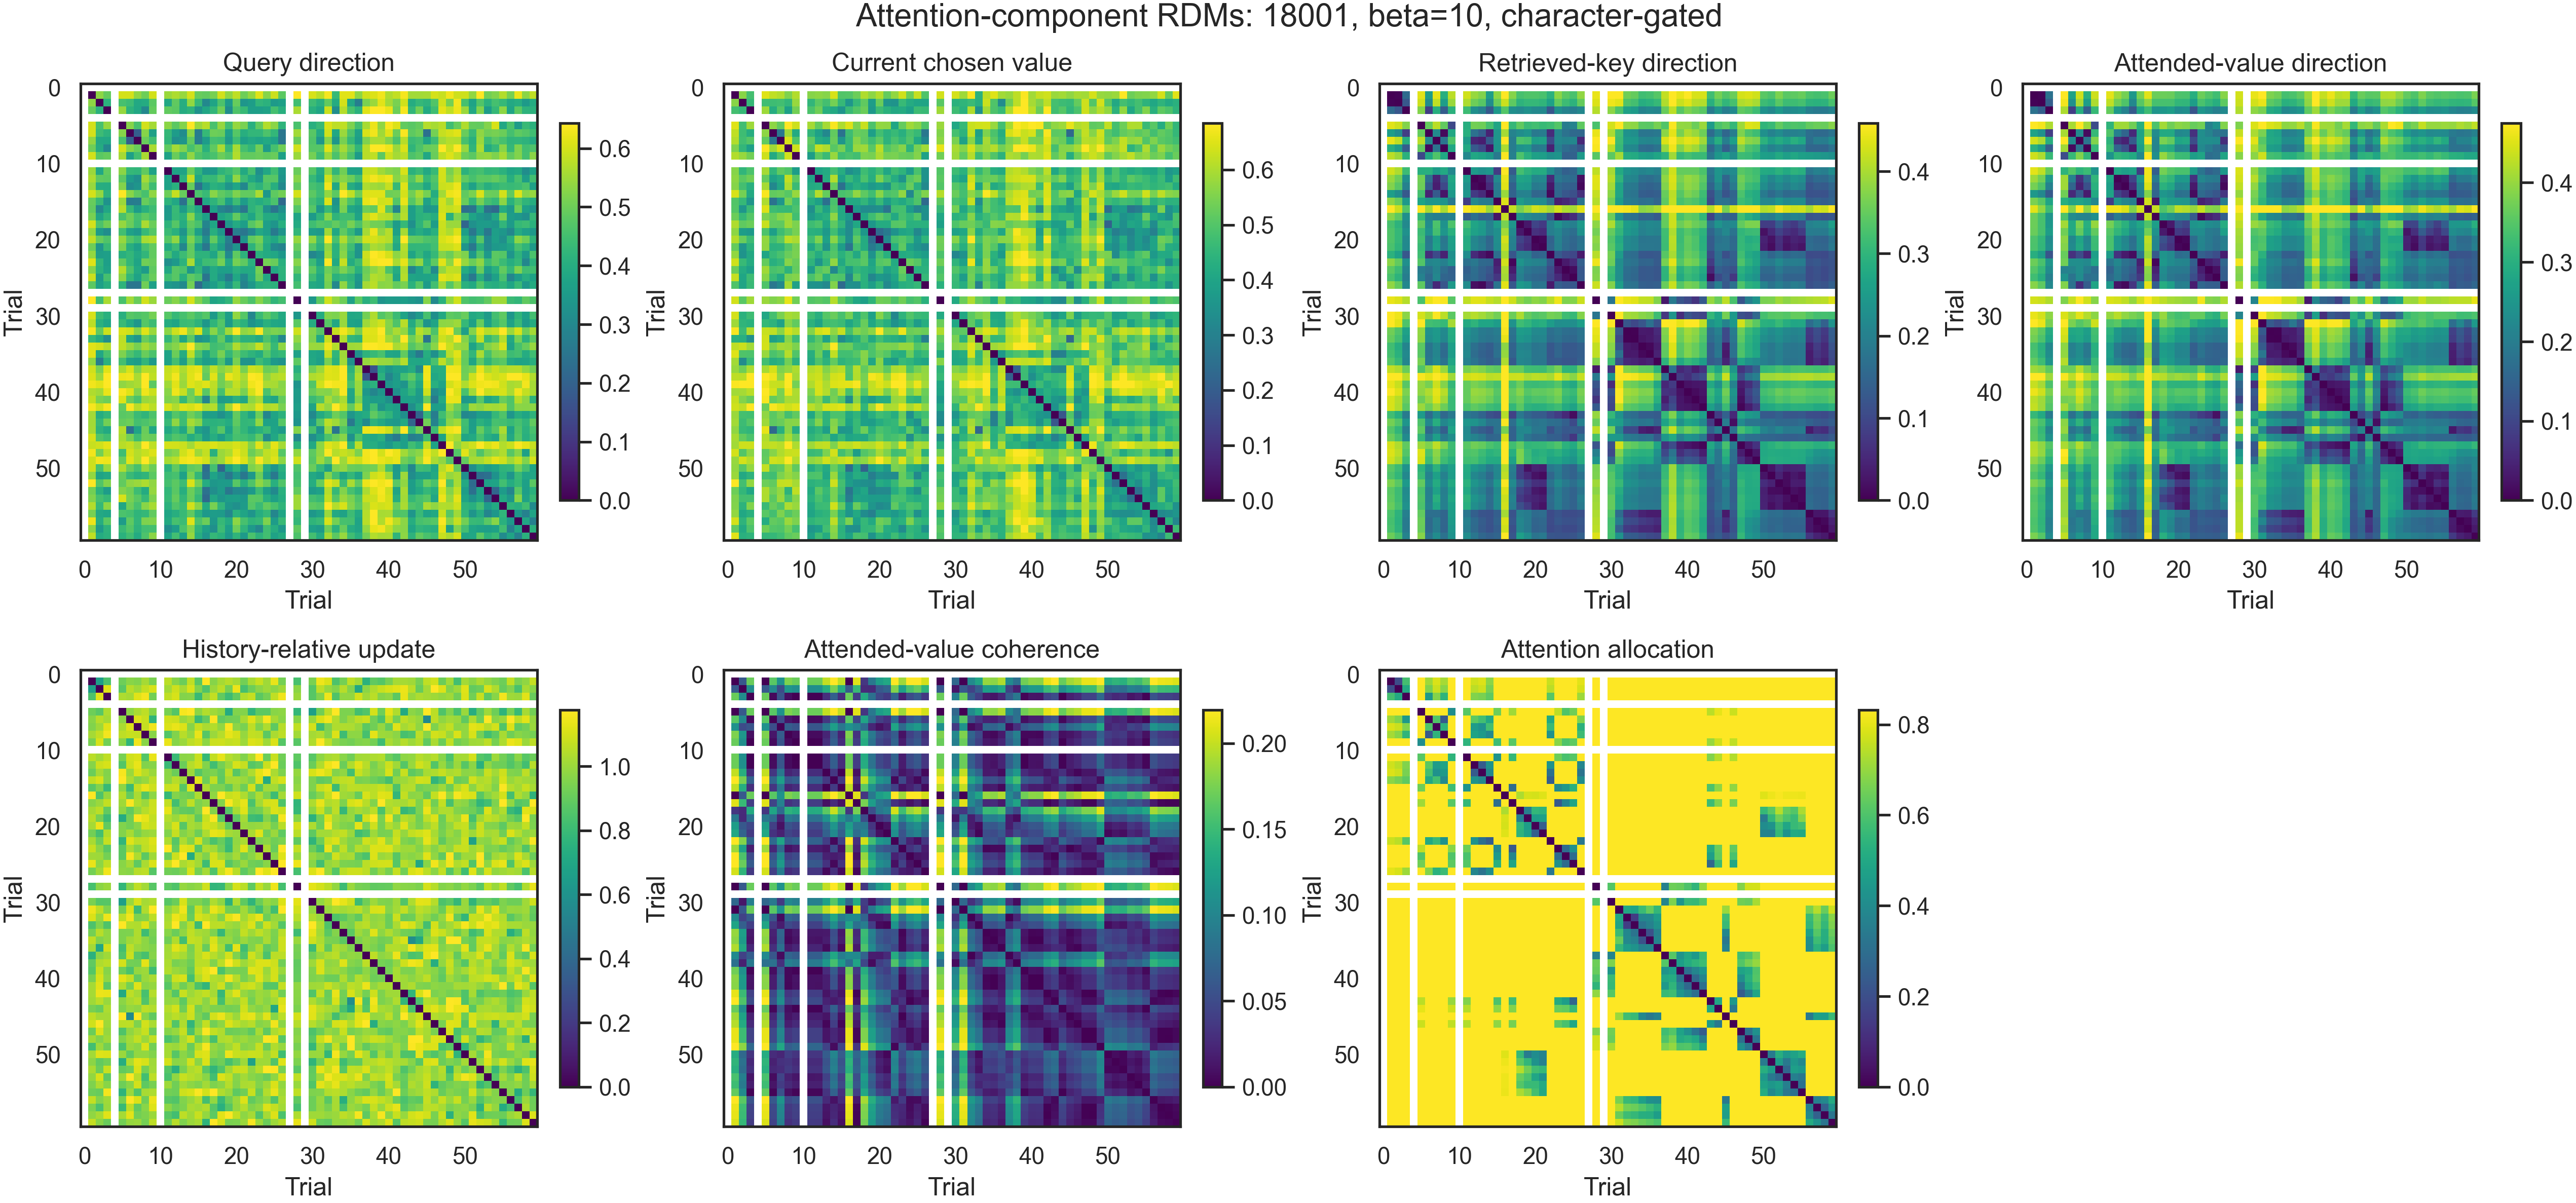

In [11]:
RDM_LABELS = {
    "attention_query_direction":
        "Query direction",
    "semantic_choice_direction":
        "Current chosen value",
    "attention_retrieved_key_direction":
        "Retrieved-key direction",
    "semantic_attention_history_direction":
        "Attended-value direction",
    "semantic_attention_history_magnitude":
        "Attended-value coherence",
    "semantic_attention_update_direction":
        "History-relative update",
    "attention_allocation":
        "Attention allocation",
}

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("white")

fig, axes = plt.subplots(
    2,
    4,
    figsize=(17, 8),
    constrained_layout=True,
)
axes = axes.ravel()

for axis, (name, rdm) in zip(axes, candidate_rdms.items()):
    finite = rdm[np.isfinite(rdm)]
    vmax = np.nanpercentile(finite, 98) if len(finite) else 1.0
    vmax = max(float(vmax), 1e-12)

    image = axis.imshow(
        rdm,
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        interpolation="none",
    )
    axis.set_title(RDM_LABELS[name])
    axis.set_xlabel("Trial")
    axis.set_ylabel("Trial")
    fig.colorbar(image, ax=axis, shrink=0.72)

for axis in axes[len(candidate_rdms):]:
    axis.axis("off")

fig.suptitle(
    f"Attention-component RDMs: {EXAMPLE_SUBJECT}, "
    f"beta={PRIMARY_BETA:g}, character-gated",
    fontsize=15,
)

plt.show()

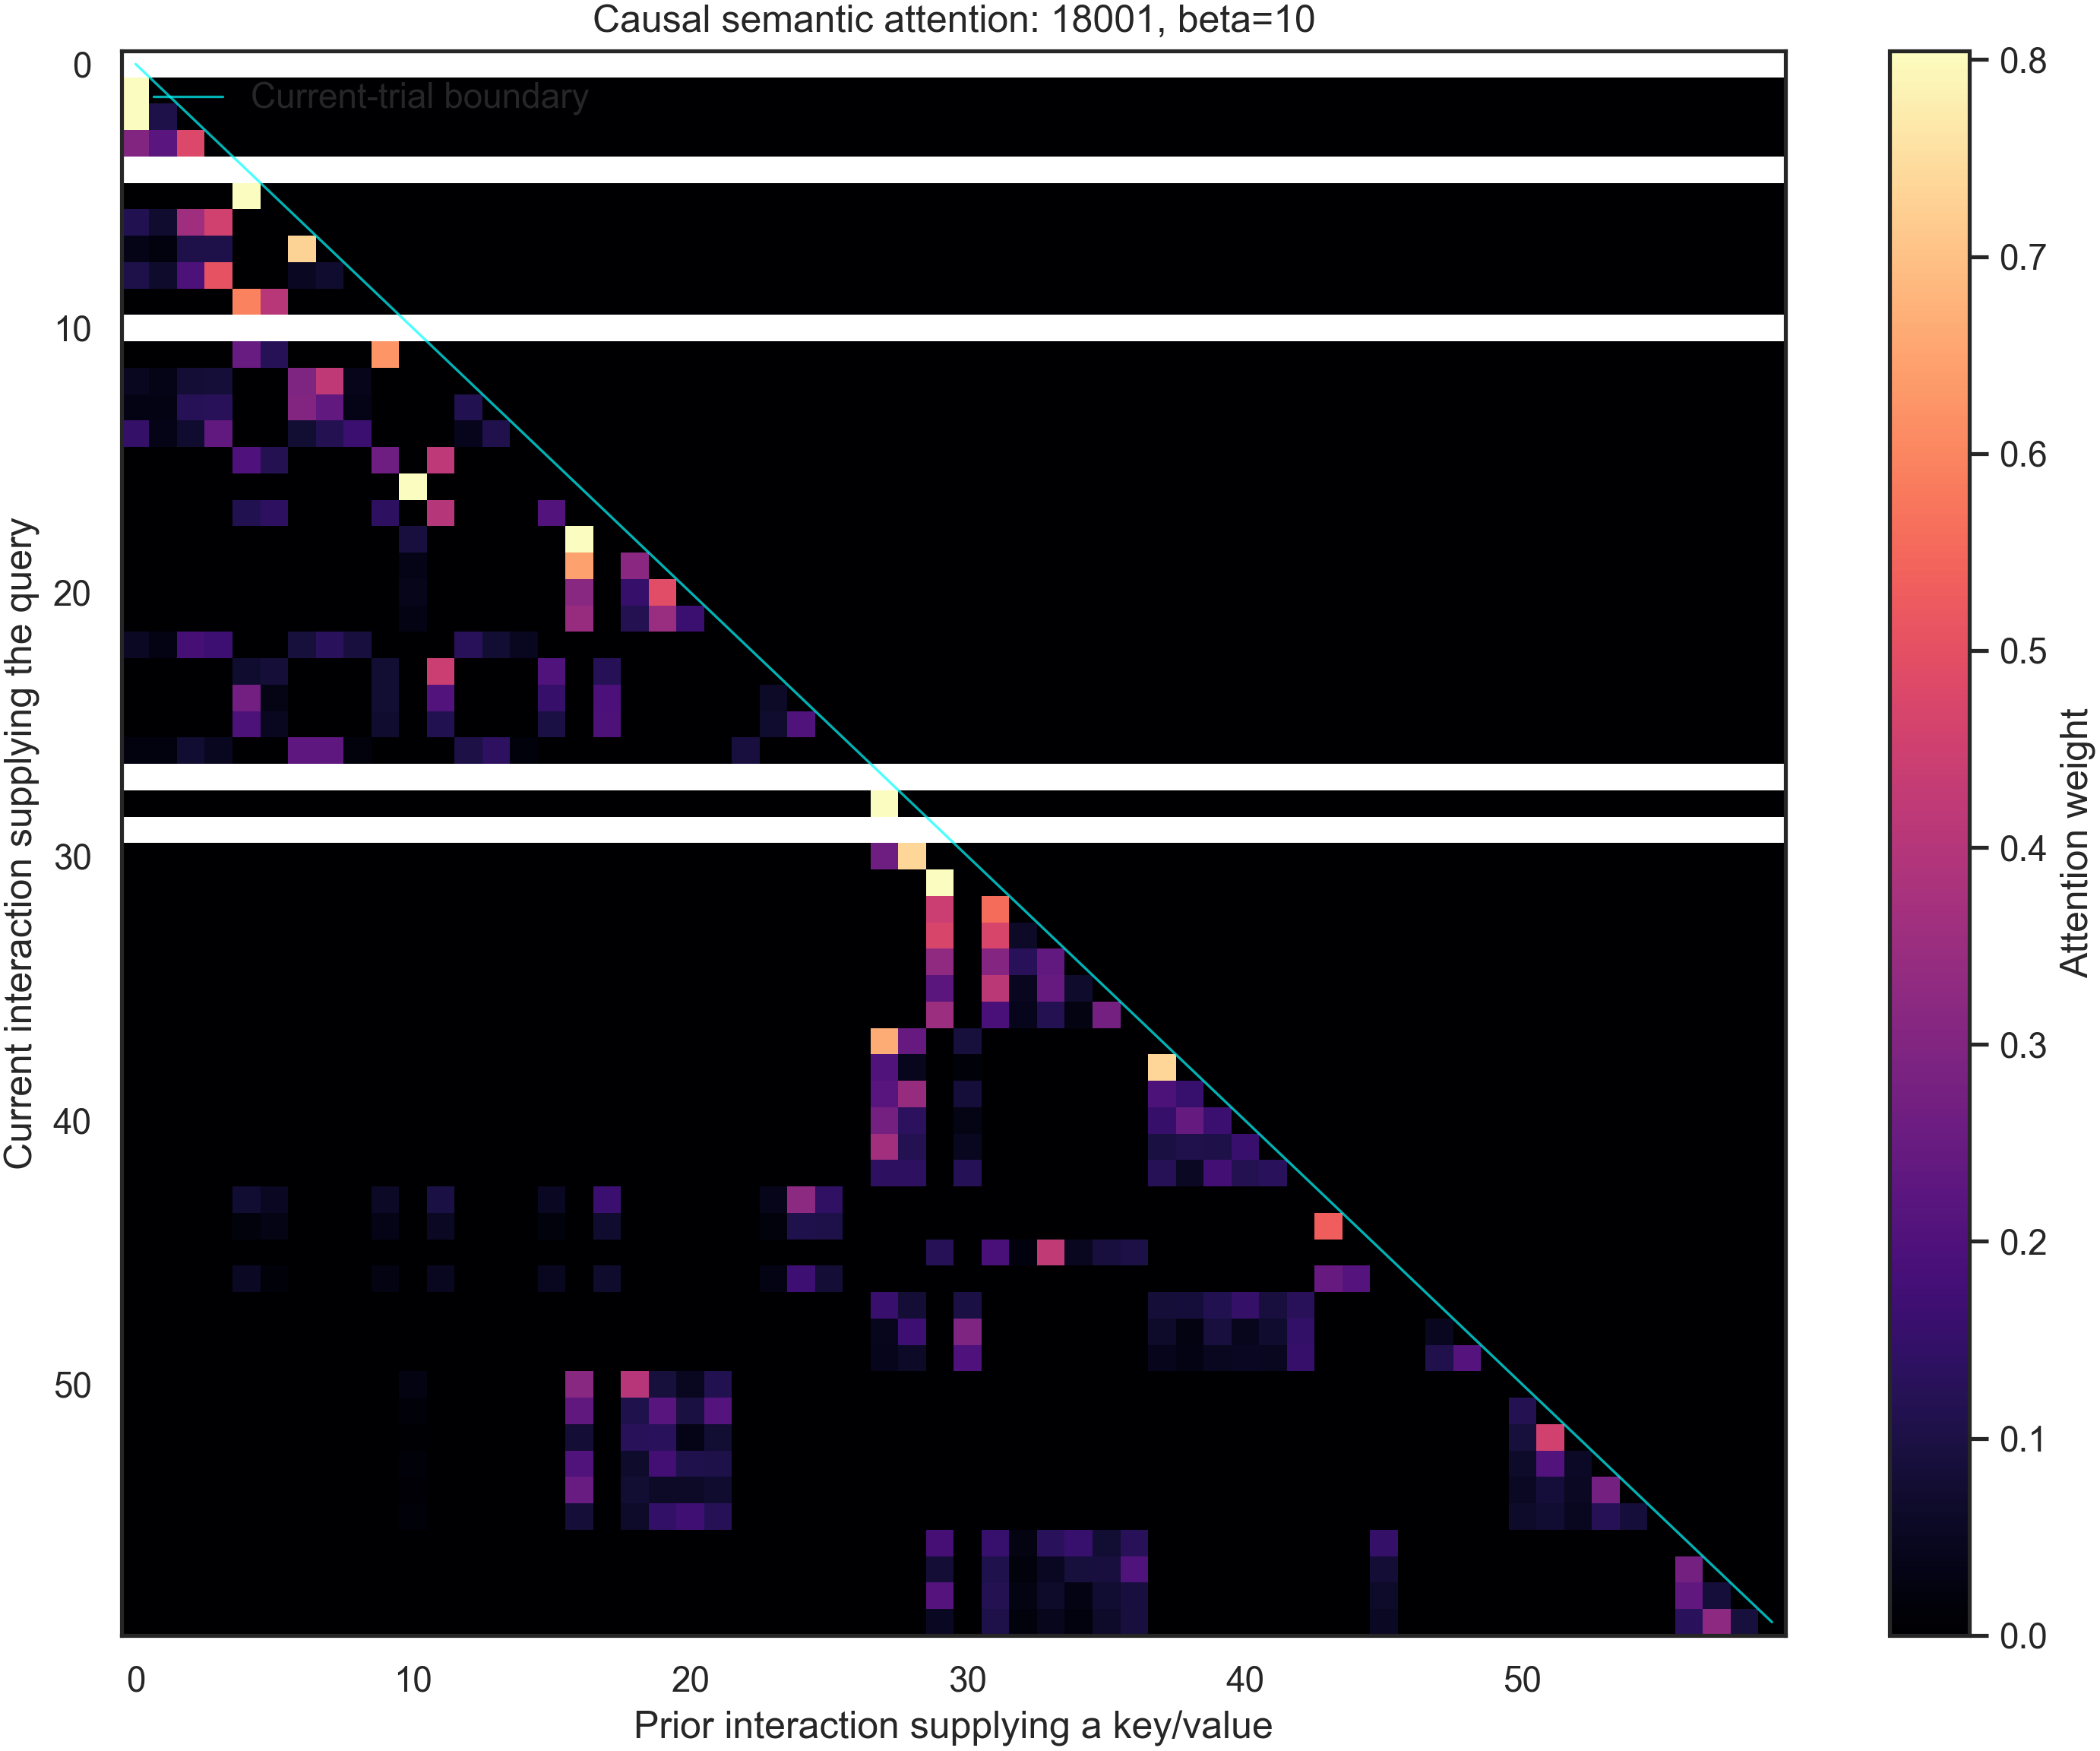

In [12]:
attention = primary_components["attention"]
positive_weights = attention[np.isfinite(attention) & (attention > 0)]
vmax = (
    np.nanpercentile(positive_weights, 98)
    if len(positive_weights)
    else 1.0
)

attention_cmap = plt.get_cmap("magma").copy()
attention_cmap.set_bad("white")

fig, axis = plt.subplots(figsize=(10, 8))

image = axis.imshow(
    attention,
    cmap=attention_cmap,
    vmin=0,
    vmax=vmax,
    interpolation="none",
    aspect="auto",
)

axis.plot(
    np.arange(len(task)),
    np.arange(len(task)),
    color="cyan",
    linewidth=0.8,
    alpha=0.7,
    label="Current-trial boundary",
)

axis.set(
    xlabel="Prior interaction supplying a key/value",
    ylabel="Current interaction supplying the query",
    title=(
        f"Causal semantic attention: {EXAMPLE_SUBJECT}, "
        f"beta={PRIMARY_BETA:g}"
    ),
)

axis.legend(frameon=False, loc="upper left")
fig.colorbar(image, ax=axis, label="Attention weight")
plt.tight_layout()
plt.show()

In [13]:
def shorten(text, width=100):
    text = " ".join(str(text).split())
    return text if len(text) <= width else text[: width - 1] + "…"


def describe_retrieval(
    components,
    choice_directions,
    current_trial,
    *,
    top_n=5,
):
    """Return the most strongly retrieved prior interactions."""
    attention = np.asarray(components["attention"], dtype=float)
    similarities = np.asarray(
        components["query_key_similarity"],
        dtype=float,
    )

    if not np.isfinite(attention[current_trial]).all():
        raise ValueError(
            f"Trial {current_trial} has no eligible history."
        )

    prior_trials = np.flatnonzero(attention[current_trial] > 0)
    order = prior_trials[
        np.argsort(attention[current_trial, prior_trials])[::-1]
    ][:top_n]

    rows = []

    for rank, prior_trial in enumerate(order, start=1):
        decision_num = int(task.loc[prior_trial, "decision_num"])
        direction = int(choice_directions[prior_trial])
        text_info = VALUE_TEXT_LOOKUP[(decision_num, direction)]

        rows.append(
            {
                "rank": rank,
                "prior_trial_index": int(prior_trial),
                "decision_num": decision_num,
                "character": task.loc[prior_trial, "character"],
                "character_interaction":
                    int(task.loc[prior_trial, "character_decision_num"]),
                "cosine_query_key":
                    similarities[current_trial, prior_trial],
                "attention_weight":
                    attention[current_trial, prior_trial],
                "chosen_response":
                    shorten(text_info["option_text"]),
            }
        )

    return pd.DataFrame(rows)


valid_attention_trials = np.flatnonzero(
    primary_components["trial_features"]["n_memories"].to_numpy() > 0
)
EXAMPLE_TRIAL_INDEX = int(valid_attention_trials[-1])

print("Current trial index:", EXAMPLE_TRIAL_INDEX)
print(
    "Current character:",
    task.loc[EXAMPLE_TRIAL_INDEX, "character"],
)
print(
    "Current situation:",
    shorten(
        task.loc[EXAMPLE_TRIAL_INDEX, "previous_slide_text"],
        width=180,
    ),
)

display(
    describe_retrieval(
        primary_components,
        example_choice_directions,
        EXAMPLE_TRIAL_INDEX,
        top_n=5,
    ).round(
        {
            "cosine_query_key": 3,
            "attention_weight": 3,
        }
    )
)

Current trial index: 59
Current character: assistant
Current situation: [Assistant character name]: “So, what’s it going to be? Are you going to live with Newcomb or me?”


,rank,prior_trial_index,decision_num,character,character_interaction,cosine_query_key,attention_weight,chosen_response
0,1,57,61,assistant,10,0.718,0.324,You: “Sounds interesting. Tell them you need t...
1,2,56,60,assistant,9,0.626,0.129,"You (cutting in):“Listen, [Mr./Mrs. Newcomb ch..."
2,3,31,34,assistant,2,0.604,0.104,You: “Is it always that hectic around here?”
3,4,36,40,assistant,7,0.594,0.094,You: “I don’t think so. Maybe another time.”
4,5,58,62,assistant,11,0.591,0.091,"You: “Yes, how about you? Can I do anything to..."


## Reusable participant-level candidate regressors

The helper below returns identically ordered RDVs of length \(60 \times 59 / 2 = 1770\) for each requested attention specification. Invalid pairs remain NaN, matching the existing RSA convention. The common pair mask should be combined with the neural and nuisance finite masks at model fitting.

Recommended model comparison:

1. Baseline nuisance structure plus query and current chosen-value RDMs.
2. Add attended-value direction and coherence.
3. Add the history-relative update.
4. Test retrieved-key and attention-allocation RDMs in separate diagnostic models.
5. Compare semantic attention against uniform, recency-only, and wrong-character controls.

Do not select beta by maximizing neural fit on the same data.

In [14]:
DEFAULT_MODEL_SPECS = {
    "uniform": {
        "beta": 0.0,
        "character_gate": True,
        "recency_tau": None,
    },
    "recency_tau_2": {
        "beta": 0.0,
        "character_gate": True,
        "recency_tau": 2.0,
    },
    **{
        f"semantic_beta_{beta:g}": {
            "beta": beta,
            "character_gate": True,
            "recency_tau": None,
        }
        for beta in BETA_GRID
        if beta > 0
    },
    f"semantic_beta_{PRIMARY_BETA:g}_plus_recency": {
        "beta": PRIMARY_BETA,
        "character_gate": True,
        "recency_tau": RECENCY_CONTROL_TAU,
    },
    f"global_semantic_beta_{PRIMARY_BETA:g}": {
        "beta": PRIMARY_BETA,
        "character_gate": False,
        "recency_tau": None,
    },
}


def build_subject_attention_rdms(
    sub_id,
    *,
    model_specs: Mapping = DEFAULT_MODEL_SPECS,
):
    """Build participant-specific attention components and matched RDVs."""
    choice_directions = participant_choice_directions(sub_id)

    models = {}

    for model_name, specification in model_specs.items():
        components = compute_attention_components(
            choice_directions,
            **specification,
        )
        rdm_bundle = make_component_rdms(components)

        models[model_name] = {
            "specification": dict(specification),
            "components": components,
            "rdms": rdm_bundle["rdms"],
            "rdvs": rdm_bundle["rdvs"],
            "common_trial_mask": rdm_bundle["common_trial_mask"],
            "common_pair_mask": rdm_bundle["common_pair_mask"],
        }

    return {
        "sub_id": sub_id,
        "choice_directions": choice_directions,
        "models": models,
    }


# Example access:
example_subject_models = build_subject_attention_rdms(EXAMPLE_SUBJECT)

example_history_rdv = example_subject_models[
    "models"
][
    f"semantic_beta_{PRIMARY_BETA:g}"
][
    "rdvs"
][
    "semantic_attention_history_direction"
]

print("Available model specifications:")
display(pd.DataFrame(DEFAULT_MODEL_SPECS).T)
print("Example history RDV:", example_history_rdv.shape)


# Deliberately opt-in: loading every behavioral file is unnecessary for
# developing and inspecting the model.
RUN_ALL_SUBJECTS = False

if RUN_ALL_SUBJECTS:
    all_subject_attention_rdms = {}
    skipped_subjects = {}

    for sub_id in incl_subs:
        try:
            all_subject_attention_rdms[sub_id] = (
                build_subject_attention_rdms(sub_id)
            )
        except Exception as error:
            skipped_subjects[sub_id] = str(error)

    print("Built subjects:", len(all_subject_attention_rdms))
    print("Skipped subjects:", len(skipped_subjects))

Available model specifications:


,beta,character_gate,recency_tau
uniform,0.0,True,None
recency_tau_2,0.0,True,2.0
semantic_beta_1,1.0,True,None
semantic_beta_2,2.0,True,None
semantic_beta_5,5.0,True,None
semantic_beta_10,10.0,True,None
semantic_beta_20,20.0,True,None
semantic_beta_10_plus_recency,10.0,True,2.0
global_semantic_beta_10,10.0,False,None


Example history RDV: (1770,)
